In [1]:
from lib.MLP import BinaryTfidfMLPClassifier
import requests
import polars as pl
import zipfile
import io
from lib.wrangling_helpers import create_classify_cols
from collections import Counter  
from lib.viz import count_plot

In [ ]:
# See results: model_results/optuna_tf_idf_mlp.csv
model = BinaryTfidfMLPClassifier().load("../models/optuna_tf_idf_mlp.pkl")

Binary classifier loaded from ../models/optuna_tf_idf_mlp.pkl


In [3]:
data_url = "https://foerderdatenbankdump.fra1.cdn.digitaloceanspaces.com/data/parquet_data.zip"

response = requests.get(data_url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    file_name = z.namelist()[0]
    with z.open(file_name) as f:
        df_all = pl.read_parquet(f)

In [4]:
df_all = create_classify_cols(df_all, "description")

In [5]:
texts = df_all['description_title_cats_compact'].to_list()
preds = model.predict(texts)
df_all = df_all.with_columns(pl.Series('pred_label', preds))

In [7]:
labels = df_all["pred_label"]
label_counts = Counter(labels)
label_counts_perc = {k: round((v / len(labels)) * 100, 2) for k, v in label_counts.items().__reversed__()}
print(f"Label Distribution: {label_counts}")
print(f"Label Distribution in %: {label_counts_perc}")

Label Distribution: Counter({0: 2349, 1: 223})
Label Distribution in %: {0: 91.33, 1: 8.67}


In [8]:
df_all.filter(pl.col("pred_label") == 1).sample(20)["description_title_cats_compact"].to_list()

['Förderung von interdisziplinären Pilotprojekten zum Thema „Neurobiologisch inspirierte Künstliche Intelligenz“ (Förderbereich: Forschung & Innovation (themenspezifisch); Förderberechtigte: Forschungseinrichtung, Hochschule, Unternehmen): Rechtsgrundlage Richtlinie zur  vom: 25.11.2024 Bundesministerium für Bildung und Forschung BAnz AT 04.12.2024 B5 Die Frist zur Einreichung von Projektskizzen endete am 06.03.2025. Weblink zur Förderrichtlinie',
 'Zuwendungen für das Jugendaufbauwerk Schleswig-Holstein (Förderbereich: Aus- & Weiterbildung, Gesundheit & Soziales, Infrastruktur; Förderberechtigte: Kommune): Rechtsgrundlage Richtlinie über die Gewährung von  vom: 17.12.2024 Ministeriums für Allgemeine und Berufliche Bildung, Wissenschaft, Forschung und Kultur Amtsblatt 2024/103 vom 25.11.2024 Anträge konnten zu folgenden Terminen gestellt werden: Anträge zu Punkt 2.1 der Richtlinie: 01.04.2025 bis 30.04.2025 Anträge zu Punkt 2.2 der Richtlinie: a) mit Maßnahmebeginn ab 01.07.2025: 01.04

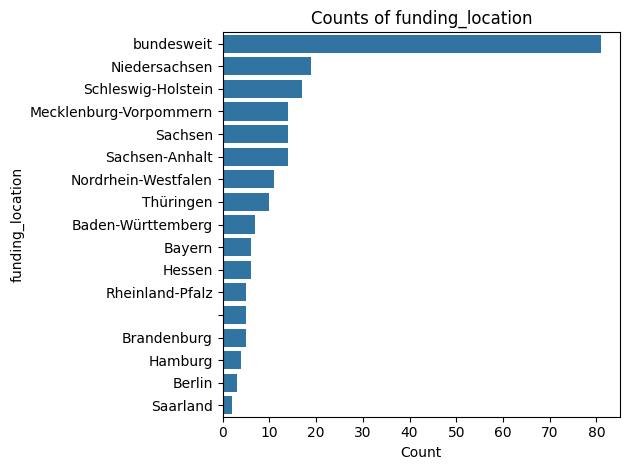

In [9]:
positives = df_all.filter(pl.col("pred_label") == 1)
count_plot(positives, "funding_location")